# Demo RandomForestClassifier

In [1]:
# from google.colab import drive
# drive.mount("/content/gdrive", force_remount=True)
# %cd '/content/gdrive/My Drive/LDS6_MachineLearning/practice/Chapter7_Random_Forest/'

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import datasets
from IPython.display import Image
from sklearn import tree
import pydotplus
import pandas as pd

In [3]:
iris = pd.read_excel("Iris.xls")
iris.head()

,sepallength,sepalwidth,petallength,petalwidth,iris
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
X = iris[['sepallength', 'sepalwidth', 'petallength', 'petalwidth']]
y = iris['iris']

In [5]:
X.head()

,sepallength,sepalwidth,petallength,petalwidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
y[:5]

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: iris, dtype: str

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3)

In [9]:
clf = RandomForestClassifier(n_estimators=100) # so cay trong rung
# lam voi: 30, 50, 70, 100, 150, 200 => chon Rung phu hop theo so luong cay (score)
# thuc hien vong lap theo so cay trong rung lst_cay = [30, 50, 70, 100]
# => tao rung theo tung gia tri trong lst_cay
# => do do chinh xac acc, neu do chinh xac = nhau => so sanh train/test r^2
# => chon model random forest co do chinh xac cao nhat, chenh lech giua train/test r^2 la it nhat
# Train model
model = clf.fit(X_train, y_train)

In [10]:
# How to show information of trees in random forest
model.estimators_[:3] # 0..99

[DecisionTreeClassifier(max_features='sqrt', random_state=1580378498),
 DecisionTreeClassifier(max_features='sqrt', random_state=1219931552),
 DecisionTreeClassifier(max_features='sqrt', random_state=1598786234)]

In [11]:
y_pred = model.predict(X_test)

In [12]:
from sklearn import metrics

In [13]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9555555555555556


In [14]:
# Make new prediction
import numpy as np
X_new = np.array([[4.7, 3.2, 1.3, 0.2],
                  [6.6, 3. , 4.4, 1.4],
                  [5.9, 3. , 5.1, 1.8]])

In [15]:
yhat_new = model.predict(X_new)
yhat_new

C:\Users\my computer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

### Find important features in sklearn

In [16]:
imp_features = pd.Series(model.feature_importances_,
                         index=X.columns).sort_values(ascending = False)

In [17]:
imp_features

petallength    0.456175
petalwidth     0.394416
sepallength    0.127287
sepalwidth     0.022122
dtype: float64

In [18]:
import matplotlib.pyplot as plt

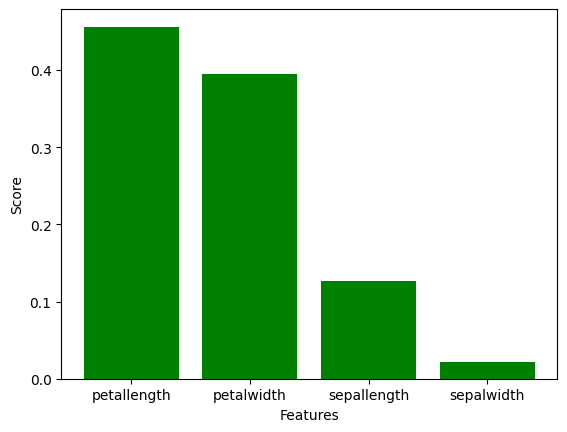

In [19]:
plt.bar(imp_features.index, imp_features, color="g")
plt.xlabel("Features")
plt.ylabel("Score")
plt.show()

In [20]:
# Build model with 2 important features
X = iris[['petallength', 'petalwidth']]
y = iris['iris']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3,random_state=20)

In [22]:
model_new = RandomForestClassifier(n_estimators=100)
# Train model
model_new.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
y_pred_new = model_new.predict(X_test)

In [24]:
print("Accuracy:", metrics.accuracy_score(y_test, y_pred_new))

Accuracy: 0.8888888888888888


In [25]:
# Make new prediction
import numpy as np
X_new = np.array([[1.3, 0.2],
                  [4.4, 1.4],
                  [5.1, 1.8]])

In [26]:
yhat_new = model_new.predict(X_new)
yhat_new

C:\Users\my computer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [27]:
# Avg max depth
max_depth = list()
for tree in model_new.estimators_:
    max_depth.append(tree.tree_.max_depth)

print("avg max depth %0.1f" % (sum(max_depth) / len(max_depth)))

avg max depth 3.2
